In [1]:
import mne
import glob
import neurokit2 as nk
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [63]:
participants = ["03", "04", "05", "06", "09", "10", "12", "13", "14", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "31", "32", "33", "34", "35", "36", "37", "38", "39", "40"]

ecg_channels = ['RA', 'LA', 'RB', 'LB', 'LL']

event_results = pd.DataFrame()
condition_results = pd.DataFrame()

for participant in participants:

    filename = glob.glob(f"D:\\ZeynepStudy\\DATA\\p{participant}\\*.vhdr")
    
    raw = mne.io.read_raw_brainvision(filename[0], preload=True)
    raw.set_channel_types({'EOG1': 'eog', 'EOG2': 'eog', 'EOG3': 'eog', 'EOG4': 'eog', 'RA': 'ecg', 'LA': 'ecg', 'RB': 'ecg', 'LB': 'ecg', 'LL': 'ecg'})
    
    ecg_data = raw.get_data(picks="ecg")
    events, _ = mne.events_from_annotations(raw)
    
    json_cond_file = f"D:\\ZeynepStudy\\DATA\\p{participant}\\expConditions.json"

    with open(json_cond_file, 'r') as f:
        expConditions = json.load(f)
        
    condition_order = expConditions['conditions_order']
    
    peaceful_keywords = ['wind', 'chime', 'piano', 'raindrop', 'bird']
    
    if participant in ("03", "04", "05"):
        sound_trigger_files = [f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_1.json", f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_2.json", f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_3.json"]
    else:
        sound_trigger_files = [f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_0.json", f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_1.json", f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_2.json"]
    
    sound_info = []
    for cond_idx, sound_file in zip(condition_order, sound_trigger_files):
        with open(sound_file, 'r') as f:
            triggers = json.load(f)
        for entry in triggers:
            if any(kw in entry["file"].lower() for kw in peaceful_keywords):
                soundType = "peaceful"
            else:
                soundType = "stressful"
            sound_info.append({
                "condition": cond_idx,
                "file": entry["file"],
                "type": soundType
            })
            
    onsets = []
    durations = []
    conditions = []
    counter = 0
    
    for ev in events:
        onset, dur, code = ev
        if code == 2:
            sound = sound_info[counter]
            
            if sound["type"] == "peaceful" and sound["condition"] == 0:
                newCode = 21
            elif sound["type"] == "peaceful" and sound["condition"] == 1:
                newCode = 22
            elif sound["type"] == "peaceful" and sound["condition"] in (2, 3):
                newCode = 23
            elif sound["type"] == "stressful" and sound["condition"] == 0:
                newCode = 25
            elif sound["type"] == "stressful" and sound["condition"] == 1:
                newCode = 26
            elif sound["type"] == "stressful" and sound["condition"] in (2, 3):
                newCode = 27
            else:
                print("Error: sound category not found")
                
            onsets.append(onset)
            durations.append(1000)
            conditions.append(newCode)
            
            counter += 1
            
    nkEvents = nk.events_create(event_onsets=onsets, event_durations=durations, event_conditions=conditions)
    
    channelQuality = []
    for chn in range(5):
        ecg = ecg_data[chn,:]
        signals, info = nk.ecg_process(ecg, sampling_rate=1000)
        meanQual = signals["ECG_Quality"].mean()
        channelQuality.append(meanQual)
        
    bestChan = np.argmax(channelQuality)
    
    ecg = ecg_data[bestChan,:]
    signals, info = nk.ecg_process(ecg, sampling_rate=1000)
    
    epochs = nk.epochs_create(signals, nkEvents, sampling_rate=1000, epochs_start=-0.1, epochs_end=5)
    analyze_epochs = nk.ecg_analyze(epochs, sampling_rate=1000)
    analyze_epochs['participant'] = participant
    event_results = pd.concat([event_results, analyze_epochs], axis=0)
    
    longEpochs = nk.epochs_create(signals, events=[onsets[0], onsets[20], onsets[40]], sampling_rate=1000, epochs_end=200)
    analyze_longEpochs = nk.ecg_intervalrelated(longEpochs)
    analyze_longEpochs['condition'] = condition_order
    analyze_longEpochs['participant'] = participant
    condition_results = pd.concat([condition_results, analyze_longEpochs], axis=0)
    
    peaks = nk.ecg_findpeaks(signals, sampling_rate=1000)
    peakEpochs = nk.epochs_create(signals, events=peaks["ECG_R_Peaks"], epochs_start=-0.5, epochs_end=0.5)
    grand_av = nk.epochs_average(peakEpochs, which="ECG_Clean", show=True)
    channel_name = ecg_channels[bestChan]
    plt.title(f"Grand Average of ECG signal for Participant {participant}, Channel: {channel_name}")
    #plt.savefig(f"D:\\ZeynepStudy\\dataAnalysis\\ECG_analysis\\p{participant}_ECG_grandAvg.png", dpi=300)
    plt.clf()
    
    hrv_indices = nk.hrv(peaks, sampling_rate=1000, show=True)
    #plt.savefig(f"D:\\ZeynepStudy\\dataAnalysis\\ECG_analysis\\p{participant}_HRV_overview.png", dpi=300)
    plt.clf()
    
#condition_results.to_excel("D:\\ZeynepStudy\\dataAnalysis\\ECG_analysis\\socPres_HRV.xlsx", index=False)
#event_results.to_excel("D:\\ZeynepStudy\\dataAnalysis\\ECG_analysis\\soundSocPres_ECG.xlsx", index=False)

Extracting parameters from D:\ZeynepStudy\DATA\p03\p03_16072024.vhdr...
Setting channel info structure...
Reading 0 ... 1896039  =      0.000 ...  1896.039 secs...
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3')]
Extracting parameters from D:\ZeynepStudy\DATA\p04\p04_2.vhdr...
Setting channel info structure...
Reading 0 ... 1398719  =      0.000 ...  1398.719 secs...
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S129')]
Extracting parameters from D:\ZeynepStudy\DATA\p05\p05_02082024.vhdr...
Setting channel info structure...
Reading 0 ... 1738599  =      0.000 ...  1738.599 secs...
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S  5')]
Extracting parameters from D:\ZeynepStudy\DATA\p06\p06_041

D:\PyCharmProjects\VSTHVR-P72\.venv\lib\site-packages\neurokit2\hrv\hrv.py:135: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(constrained_layout=False)


Extracting parameters from D:\ZeynepStudy\DATA\p29\p29_1604025.vhdr...
Setting channel info structure...
Reading 0 ... 958359  =      0.000 ...   958.359 secs...
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2')]
Extracting parameters from D:\ZeynepStudy\DATA\p31\p31_15042025.vhdr...
Setting channel info structure...
Reading 0 ... 924899  =      0.000 ...   924.899 secs...
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S  5')]
Extracting parameters from D:\ZeynepStudy\DATA\p32\p32_17042025.vhdr...
Setting channel info structure...
Reading 0 ... 1022619  =      0.000 ...  1022.619 secs...
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3')]
Extracting parameters from D:\ZeynepStudy\DATA\p33\p33_16042025.vhdr...
Setting channel info structure...


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [64]:
epochs

{np.str_('1'):             ECG_Raw  ECG_Clean    ECG_Rate  ECG_Quality  ECG_R_Peaks  \
 -0.100000  0.000284   0.000206  103.376364     0.841373            0   
 -0.099000  0.000313   0.000205  103.378324     0.841373            0   
 -0.098000  0.000327   0.000203  103.380283     0.841373            0   
 -0.096999  0.000260   0.000200  103.382240     0.841373            0   
 -0.095999  0.000237   0.000196  103.384195     0.841373            0   
 ...             ...        ...         ...          ...          ...   
  4.995999  0.000347   0.000125   96.400274     0.985215            0   
  4.996999  0.000338   0.000126   96.393225     0.985215            0   
  4.998000  0.000346   0.000127   96.386171     0.985215            0   
  4.999000  0.000352   0.000128   96.379113     0.985215            0   
  5.000000  0.000333   0.000129   96.372052     0.985215            0   
 
            ECG_P_Peaks  ECG_P_Onsets  ECG_P_Offsets  ECG_Q_Peaks  \
 -0.100000            0             0  

In [10]:
participants = ["32"]

ecg_channels = ['RA', 'LA', 'RB', 'LB', 'LL']

event_results = pd.DataFrame()
condition_results = pd.DataFrame()

for participant in participants:

    filename = glob.glob(f"D:\\ZeynepStudy\\DATA\\p{participant}\\*.vhdr")
    
    raw = mne.io.read_raw_brainvision(filename[0], preload=True)
    raw.set_channel_types({'EOG1': 'eog', 'EOG2': 'eog', 'EOG3': 'eog', 'EOG4': 'eog', 'RA': 'ecg', 'LA': 'ecg', 'RB': 'ecg', 'LB': 'ecg', 'LL': 'ecg'})
    
    ecg_data = raw.get_data(picks="ecg")
    events, _ = mne.events_from_annotations(raw)
    
    json_cond_file = f"D:\\ZeynepStudy\\DATA\\p{participant}\\expConditions.json"

    with open(json_cond_file, 'r') as f:
        expConditions = json.load(f)
        
    condition_order = expConditions['conditions_order']
    
    peaceful_keywords = ['wind', 'chime', 'piano', 'raindrop', 'bird']
    
    if participant in ("03", "04", "05"):
        sound_trigger_files = [f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_1.json", f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_2.json", f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_3.json"]
    else:
        sound_trigger_files = [f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_0.json", f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_1.json", f"D:\\ZeynepStudy\\DATA\\p{participant}\\sound_schedule_balanced_with_triggers_2.json"]
    
    sound_info = []
    for cond_idx, sound_file in zip(condition_order, sound_trigger_files):
        with open(sound_file, 'r') as f:
            triggers = json.load(f)
        for entry in triggers:
            if any(kw in entry["file"].lower() for kw in peaceful_keywords):
                soundType = "peaceful"
            else:
                soundType = "stressful"
            sound_info.append({
                "condition": cond_idx,
                "file": entry["file"],
                "type": soundType
            })
            
    onsets = []
    durations = []
    conditions = []
    counter = 0
    
    for ev in events:
        onset, dur, code = ev
        if code == 2:
            sound = sound_info[counter]
            
            if sound["type"] == "peaceful" and sound["condition"] == 0:
                newCode = 21
            elif sound["type"] == "peaceful" and sound["condition"] == 1:
                newCode = 22
            elif sound["type"] == "peaceful" and sound["condition"] in (2, 3):
                newCode = 23
            elif sound["type"] == "stressful" and sound["condition"] == 0:
                newCode = 25
            elif sound["type"] == "stressful" and sound["condition"] == 1:
                newCode = 26
            elif sound["type"] == "stressful" and sound["condition"] in (2, 3):
                newCode = 27
            else:
                print("Error: sound category not found")
                
            onsets.append(onset)
            durations.append(1000)
            conditions.append(newCode)
            
            counter += 1
            
    nkEvents = nk.events_create(event_onsets=onsets, event_durations=durations, event_conditions=conditions)
    
    channelQuality = []
    for chn in range(5):
        ecg = ecg_data[chn,:]
        signals, info = nk.ecg_process(ecg, sampling_rate=1000)
        meanQual = signals["ECG_Quality"].mean()
        channelQuality.append(meanQual)
        
    bestChan = np.argmax(channelQuality)
    
    ecg = ecg_data[bestChan,:]
    signals, info = nk.ecg_process(ecg, sampling_rate=1000)

Extracting parameters from D:\ZeynepStudy\DATA\p32\p32_17042025.vhdr...
Setting channel info structure...
Reading 0 ... 1022619  =      0.000 ...  1022.619 secs...
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3')]


In [11]:
clean_signals = nk.ecg_clean(ecg, sampling_rate=1000)

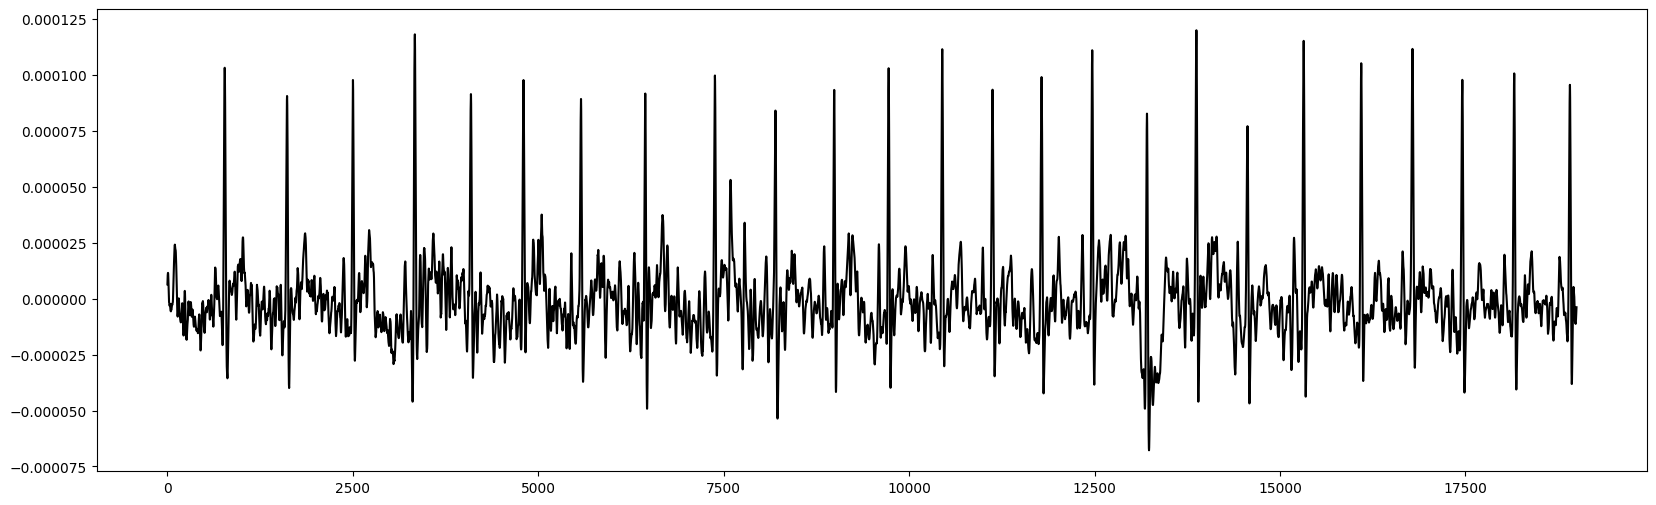

In [17]:
plt.figure(figsize=(20,6))
plt.plot(clean_signals[1000:20000,], 'k')
plt.savefig("D:\\ZeynepStudy\\figures\\exampleECG.png", dpi=300)